In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score,classification_report, confusion_matrix, accuracy_score

In [44]:
df=pd.read_csv('mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [45]:
df.shape

(8124, 23)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [47]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [48]:
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [49]:
#target encoding
df["class"] = df["class"].map({"e": 0, "p": 1})

#one hot encoding for categorical features
X = pd.get_dummies(df.drop(columns=["class"]))
y = df["class"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling features (standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled = scaler.transform(X_test)          

In [51]:
k_values = range(2, 151) 
train_f1 = []
test_f1 = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # score on train data
    train_pred = knn.predict(X_train_scaled)
    train_f1.append(f1_score(y_train, train_pred))

    # score on test data (unseen data)
    test_pred = knn.predict(X_test_scaled)
    test_f1.append(f1_score(y_test, test_pred))

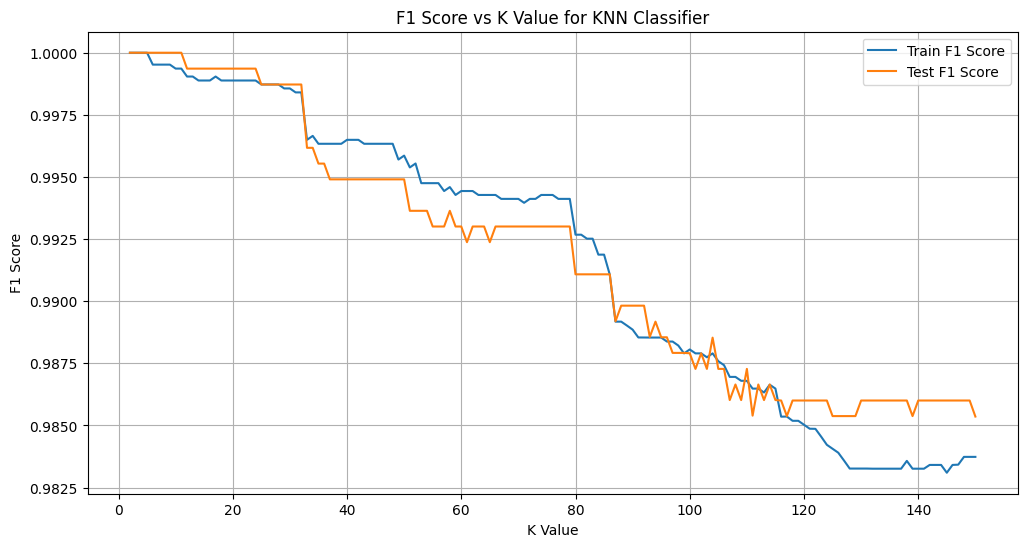

In [52]:
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_f1, label='Train F1 Score')
plt.plot(k_values, test_f1, label='Test F1 Score')
plt.title('F1 Score vs K Value for KNN Classifier')
plt.xlabel('K Value')
plt.ylabel('F1 Score')
plt.legend()
plt.grid()
plt.show()

In [53]:
best_index = test_f1.index(max(test_f1))
best_k = list(k_values)[best_index]
best_score = test_f1[best_index]

print(f"Best K: {best_k}")
print(f"Best Testing F1 Score: {best_score:.4f}")

Best K: 2
Best Testing F1 Score: 1.0000


In [54]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       843
           1       0.98      0.99      0.99       782

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



In [57]:
conf_matrix = confusion_matrix(y_test, test_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[828  15]
 [  8 774]]


### Conclusion:
The KNN classifier was trained and evaluated for K values ranging from 2 to 150 using the F1-score. The results showed that K = 2 achieved the highest testing F1-score, making it the optimal value for this dataset. The training and testing F1-score curves remained very close, indicating good generalization with no significant overfitting. As K increased, both scores gradually decreased, suggesting that very large K values led to slight underfitting. Therefore, K = 2 provides the best balance of performance and generalization for this classification task.